<a href="https://colab.research.google.com/github/SitiFadhilahRahmi/JST/blob/main/Klasifikasi_Obesitas_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load & Analisis Data**

In [133]:
# Langkah 1: Download dataset dari UCI
!wget -O obesity_dataset.zip "https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"

# Ekstrak file ZIP
!unzip -o obesity_dataset.zip

--2025-10-17 15:36:05--  https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘obesity_dataset.zip’

obesity_dataset.zip     [ <=>                ]  56.32K  --.-KB/s    in 0.03s   

2025-10-17 15:36:05 (1.66 MB/s) - ‘obesity_dataset.zip’ saved [57676]

Archive:  obesity_dataset.zip
  inflating: ObesityDataSet_raw_and_data_sinthetic.csv  


In [134]:
import pandas as pd
# Baca dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Tampilkan 5 baris pertama
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [135]:
# Cek informasi kolom
print(df.info())

# Cek distribusi target (NObesity)
print(df['NObeyesdad'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [136]:
missing_values = df.isnull().sum()
print(missing_values)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


# **Preprocessing**

**Pisahkan Fitur dan Label**

In [137]:
print(df.columns)

#Pisahkan fitur dan label
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


**Encode Label**

Merubah target yang tadinya berupa teks menjadi angka

In [138]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


**Encode Fitur Kategorikal**

Encoding fitur yang masih berupa string menjadi numerik menggunakan One Hot Encoding

In [139]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='object')
Numeric columns: Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')


In [140]:
# One-hot encode kolom kategorikal
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Setelah encoding, jumlah kolom:", X_encoded.shape[1])

Setelah encoding, jumlah kolom: 23


**Normalisasi Data Numerik**

In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

**Train Test Split**

Membagi data menjadi 80% data training dan 20% data testing

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing :", X_test.shape)

Ukuran data training: (1688, 23)
Ukuran data testing : (423, 23)


# **Pemodelan Dengan 2 Hidden Layer**

**Import library tensorflow dan keras**

In [143]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Jumlah Kelas Output**

In [144]:
num_classes = len(label_encoder.classes_)
print("Jumlah kelas:", num_classes)

Jumlah kelas: 7


**Membuat Model**

Hidden layer pertama: 128 neuron

Hidden Layer kedua: 64 neuron

Output Layer: Softmax dengan jumlah neuron = jumlah kelas

In [145]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,783 (46.03 KB)

 Trainable params: 11,783 (46.03 KB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [146]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training Model**

In [147]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3477 - loss: 1.7458 - val_accuracy: 0.5680 - val_loss: 1.2176
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6515 - loss: 1.0601 - val_accuracy: 0.6805 - val_loss: 0.8957
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7410 - loss: 0.7611 - val_accuracy: 0.7367 - val_loss: 0.7376
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7939 - loss: 0.6391 - val_accuracy: 0.7988 - val_loss: 0.6321
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8557 - loss: 0.4950 - val_accuracy: 0.8195 - val_loss: 0.5590
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8901 - loss: 0.4132 - val_accuracy: 0.8491 - val_loss: 0.4952
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8925 - loss: 0.3815 - val_accuracy: 0.8402 - val_loss: 0.4546
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8921 - loss: 0.3316 - val_accuracy: 0.8521 - v

# **Evaluasi Model**

**Cek Akurasi**

In [148]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9314


**Melakukan Prediksi**

In [149]:
# Prediksi probabilitas
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


**Akurasi dan F1-Score**

In [150]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi pada data uji: {acc:.4f}")

# F1-score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score (macro): {f1:.4f}")

# Laporan lengkap per kelas
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Akurasi pada data uji: 0.9314
F1-score (macro): 0.9296

=== Classification Report ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.95        54
      Normal_Weight       0.89      0.83      0.86        58
     Obesity_Type_I       0.92      0.99      0.95        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.85      0.88      0.86        58
Overweight_Level_II       0.95      0.90      0.92        58

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



**Confusion Matrix**

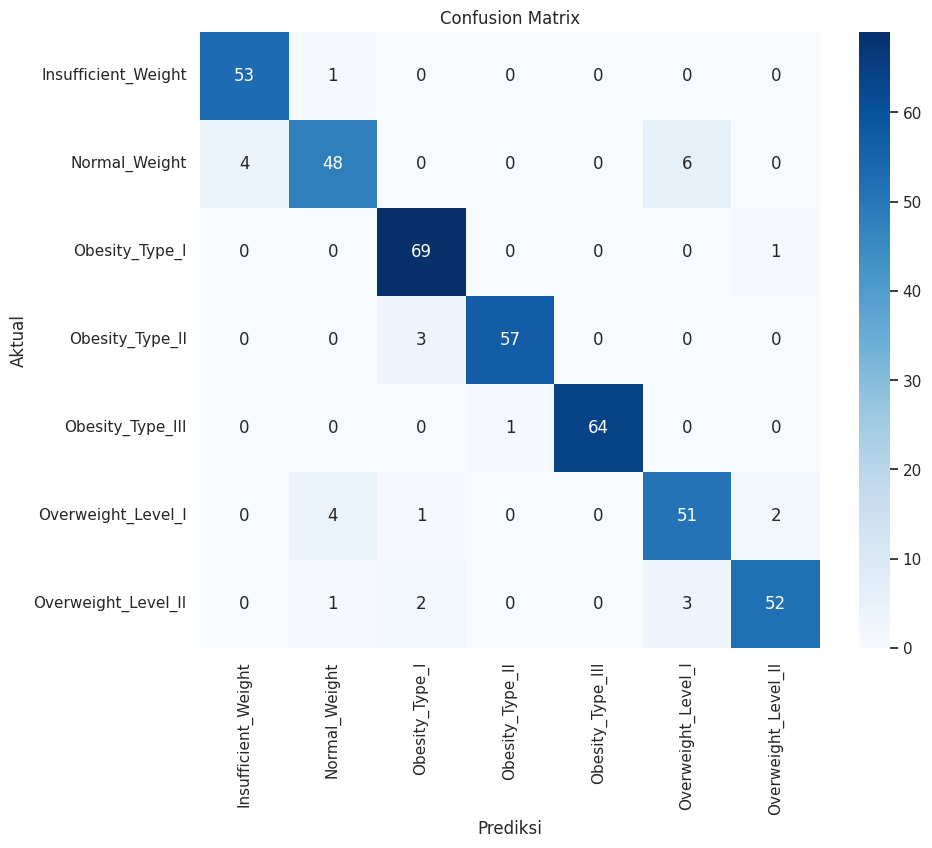

In [151]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


**Simpan Model dalam HDF5**

In [152]:
model.save('model_obesitas.h5')
print("✅ Model berhasil disimpan dalam format HDF5 (model_obesitas.h5)")

✅ Model berhasil disimpan dalam format HDF5 (model_obesitas.h5)
